In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, fetch_openml

# For reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


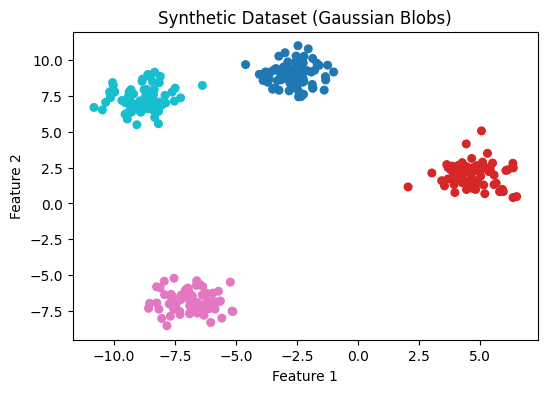

Dataset shape: (300, 2)


In [6]:
# Generate synthetic dataset (Gaussian blobs)
from sklearn.datasets import make_blobs

X_synthetic, y_synthetic = make_blobs(
    n_samples=300,   # 300 data points
    centers=4,       # 4 natural clusters
    cluster_std=0.8, # how spread out the clusters are
    random_state=42
)

# Quick plot to see what it looks like
plt.figure(figsize=(6,4))
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_synthetic, cmap='tab10', s=30)
plt.title("Synthetic Dataset (Gaussian Blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print(f"Dataset shape: {X_synthetic.shape}")


In [7]:
# Load MNIST dataset (we use a small subset to keep it fast)
from sklearn.datasets import fetch_openml

print("Loading MNIST... this may take a minute...")

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_mnist = mnist.data[:3000]   # only first 3000 samples
y_mnist = mnist.target[:3000]

# Normalize pixel values to be between 0 and 1
X_mnist = X_mnist / 255.0

print(f"MNIST shape: {X_mnist.shape}")
print(f"Number of classes: {len(set(y_mnist))}")
print("Done!")


Loading MNIST... this may take a minute...
MNIST shape: (3000, 784)
Number of classes: 10
Done!


In [8]:
def kmeans(X, k, max_iters=100, random_state=None):
    """
    K-means clustering from scratch.
    X: data points
    k: number of clusters
    """
    rng = np.random.default_rng(random_state)
    
    # Step 1: Pick k random points as starting centers
    idx = rng.choice(len(X), k, replace=False)
    centers = X[idx].copy()
    
    for _ in range(max_iters):
        # Step 2: Assign each point to nearest center
        distances = np.linalg.norm(X[:, None] - centers[None, :], axis=2)
        labels = np.argmin(distances, axis=1)
        
        # Step 3: Move centers to mean of their cluster
        new_centers = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        
        # Step 4: Stop if centers didn't move
        if np.allclose(centers, new_centers):
            break
            
        centers = new_centers
    
    return labels, centers

print("K-means implemented successfully! ✅")

K-means implemented successfully! ✅


In [9]:
def kmeans_plus_plus(X, k, max_iters=100, random_state=None):
    """
    K-means++ clustering from scratch.
    Same as k-means but with smarter initialization.
    """
    rng = np.random.default_rng(random_state)
    
    # Step 1: Pick the FIRST center randomly
    first_idx = rng.choice(len(X))
    centers = [X[first_idx].copy()]
    
    # Step 2: Pick remaining centers smartly
    for _ in range(k - 1):
        # Calculate distance from each point to nearest center
        distances = np.array([
            min(np.linalg.norm(x - c)**2 for c in centers)
            for x in X
        ])
        
        # Pick next center with probability proportional to distance
        probabilities = distances / distances.sum()
        next_idx = rng.choice(len(X), p=probabilities)
        centers.append(X[next_idx].copy())
    
    centers = np.array(centers)
    
    # Step 3: Run normal k-means from these smart centers
    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, None] - centers[None, :], axis=2)
        labels = np.argmin(distances, axis=1)
        new_centers = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        
        if np.allclose(centers, new_centers):
            break
            
        centers = new_centers
    
    return labels, centers

print("K-means++ implemented successfully! ✅")

K-means++ implemented successfully! ✅


In [10]:
def compute_inertia(X, labels, centers):
    """
    Inertia = sum of squared distances of each point to its cluster center.
    Lower is better!
    """
    inertia = 0
    for j in range(len(centers)):
        cluster_points = X[labels == j]
        if len(cluster_points) > 0:
            inertia += np.sum((cluster_points - centers[j]) ** 2)
    return inertia

print("Inertia function ready! ✅")

Inertia function ready! ✅


In [11]:
# Run multiple trials and compare k-means vs k-means++
n_trials = 50  # run each algorithm 50 times
k = 4          # number of clusters (we know synthetic has 4)

inertias_kmeans = []
inertias_kmeanspp = []

for trial in range(n_trials):
    # Run k-means
    labels_km, centers_km = kmeans(X_synthetic, k, random_state=trial)
    inertia_km = compute_inertia(X_synthetic, labels_km, centers_km)
    inertias_kmeans.append(inertia_km)
    
    # Run k-means++
    labels_pp, centers_pp = kmeans_plus_plus(X_synthetic, k, random_state=trial)
    inertia_pp = compute_inertia(X_synthetic, labels_pp, centers_pp)
    inertias_kmeanspp.append(inertia_pp)

print(f"K-means    — Mean inertia: {np.mean(inertias_kmeans):.2f}, Std: {np.std(inertias_kmeans):.2f}")
print(f"K-means++  — Mean inertia: {np.mean(inertias_kmeanspp):.2f}, Std: {np.std(inertias_kmeanspp):.2f}")

K-means    — Mean inertia: 1178.71, Std: 1363.12
K-means++  — Mean inertia: 514.85, Std: 457.13


/var/folders/qm/ldxdf91x4bl6dxp0kqnjh5640000gn/T/ipykernel_4282/1414639259.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([inertias_kmeans, inertias_kmeanspp], labels=['K-means', 'K-means++'])


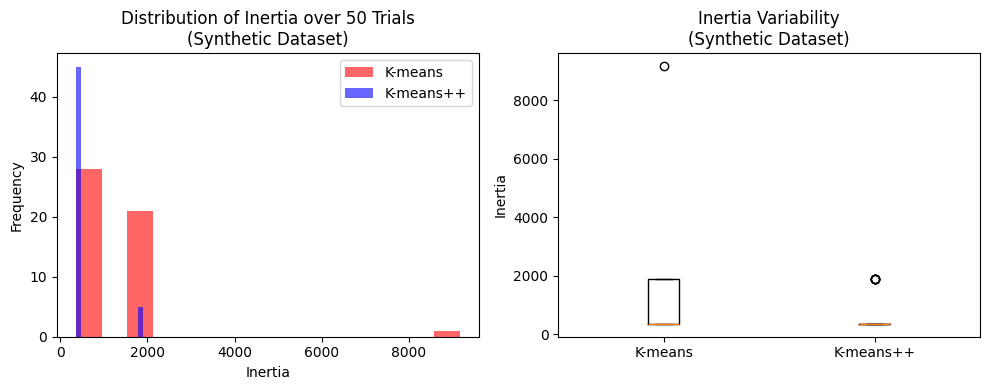

In [12]:
plt.figure(figsize=(10, 4))

# Plot 1: Distribution of inertias
plt.subplot(1, 2, 1)
plt.hist(inertias_kmeans, bins=15, alpha=0.6, color='red', label='K-means')
plt.hist(inertias_kmeanspp, bins=15, alpha=0.6, color='blue', label='K-means++')
plt.xlabel('Inertia')
plt.ylabel('Frequency')
plt.title('Distribution of Inertia over 50 Trials\n(Synthetic Dataset)')
plt.legend()

# Plot 2: Variability comparison
plt.subplot(1, 2, 2)
plt.boxplot([inertias_kmeans, inertias_kmeanspp], labels=['K-means', 'K-means++'])
plt.ylabel('Inertia')
plt.title('Inertia Variability\n(Synthetic Dataset)')

plt.tight_layout()
plt.show()

In [13]:
# Run trials on MNIST
n_trials = 20  # fewer trials because MNIST is slower
k = 10         # 10 clusters (one per digit 0-9)

inertias_kmeans_mnist = []
inertias_kmeanspp_mnist = []

print("Running trials on MNIST...")
for trial in range(n_trials):
    if trial % 5 == 0:
        print(f"  Trial {trial}/{n_trials}...")
    
    labels_km, centers_km = kmeans(X_mnist, k, random_state=trial)
    inertia_km = compute_inertia(X_mnist, labels_km, centers_km)
    inertias_kmeans_mnist.append(inertia_km)
    
    labels_pp, centers_pp = kmeans_plus_plus(X_mnist, k, random_state=trial)
    inertia_pp = compute_inertia(X_mnist, labels_pp, centers_pp)
    inertias_kmeanspp_mnist.append(inertia_pp)

print(f"\nK-means    — Mean inertia: {np.mean(inertias_kmeans_mnist):.2f}, Std: {np.std(inertias_kmeans_mnist):.2f}")
print(f"K-means++  — Mean inertia: {np.mean(inertias_kmeanspp_mnist):.2f}, Std: {np.std(inertias_kmeanspp_mnist):.2f}")

Running trials on MNIST...
  Trial 0/20...
  Trial 5/20...
  Trial 10/20...
  Trial 15/20...

K-means    — Mean inertia: 115606.31, Std: 517.77
K-means++  — Mean inertia: 115704.07, Std: 559.32


/var/folders/qm/ldxdf91x4bl6dxp0kqnjh5640000gn/T/ipykernel_4282/1126459308.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([inertias_kmeans_mnist, inertias_kmeanspp_mnist],


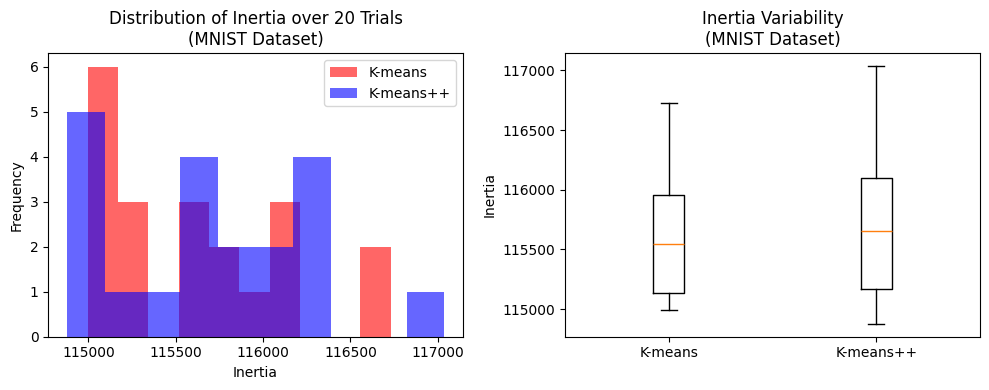

In [14]:
plt.figure(figsize=(10, 4))

# Plot 1: Distribution
plt.subplot(1, 2, 1)
plt.hist(inertias_kmeans_mnist, bins=10, alpha=0.6, color='red', label='K-means')
plt.hist(inertias_kmeanspp_mnist, bins=10, alpha=0.6, color='blue', label='K-means++')
plt.xlabel('Inertia')
plt.ylabel('Frequency')
plt.title('Distribution of Inertia over 20 Trials\n(MNIST Dataset)')
plt.legend()

# Plot 2: Boxplot
plt.subplot(1, 2, 2)
plt.boxplot([inertias_kmeans_mnist, inertias_kmeanspp_mnist], 
            labels=['K-means', 'K-means++'])
plt.ylabel('Inertia')
plt.title('Inertia Variability\n(MNIST Dataset)')

plt.tight_layout()
plt.show()

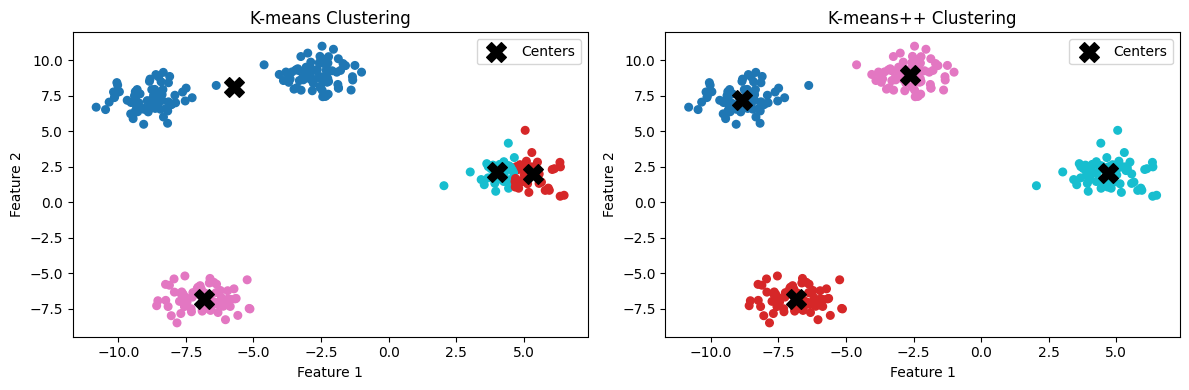

In [15]:
# Visual comparison of clustering on synthetic data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Run once for visualization
labels_km, centers_km = kmeans(X_synthetic, k=4, random_state=0)
labels_pp, centers_pp = kmeans_plus_plus(X_synthetic, k=4, random_state=0)

# K-means plot
axes[0].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=labels_km, cmap='tab10', s=30)
axes[0].scatter(centers_km[:, 0], centers_km[:, 1], c='black', marker='X', s=200, label='Centers')
axes[0].set_title('K-means Clustering')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()

# K-means++ plot
axes[1].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=labels_pp, cmap='tab10', s=30)
axes[1].scatter(centers_pp[:, 0], centers_pp[:, 1], c='black', marker='X', s=200, label='Centers')
axes[1].set_title('K-means++ Clustering')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.show()

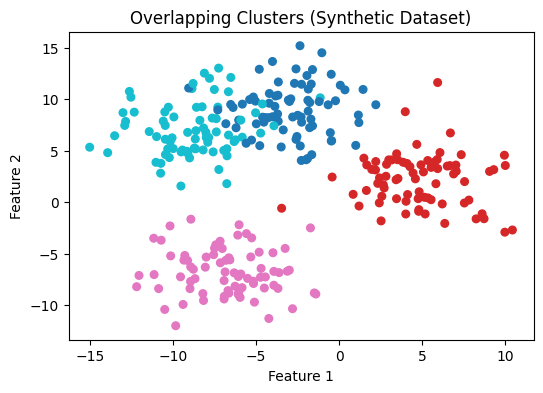

In [16]:
# Generate overlapping clusters (harder case)
X_overlap, y_overlap = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=2.5,  # much higher spread = overlapping clusters
    random_state=42
)

# Plot to see the overlap
plt.figure(figsize=(6,4))
plt.scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap, cmap='tab10', s=30)
plt.title("Overlapping Clusters (Synthetic Dataset)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

/var/folders/qm/ldxdf91x4bl6dxp0kqnjh5640000gn/T/ipykernel_4282/1920937056.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([inertias_kmeans_overlap, inertias_kmeanspp_overlap],


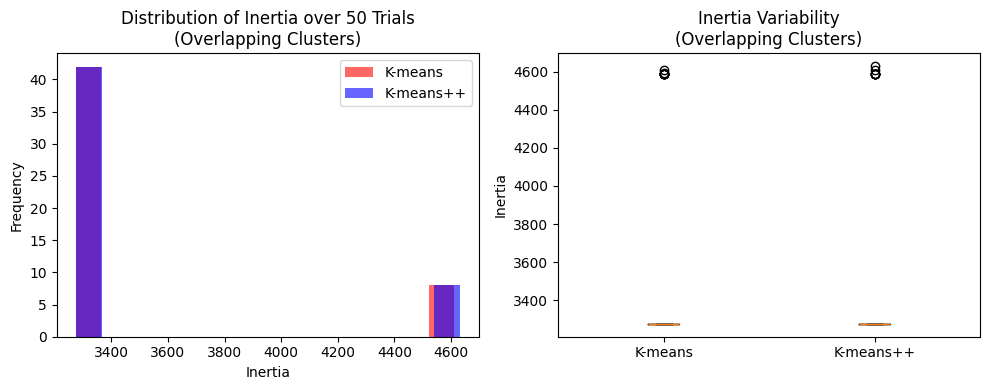

K-means    — Mean: 3486.41, Std: 482.23
K-means++  — Mean: 3487.04, Std: 483.90


In [17]:
# Run trials on overlapping clusters
n_trials = 50
k = 4

inertias_kmeans_overlap = []
inertias_kmeanspp_overlap = []

for trial in range(n_trials):
    labels_km, centers_km = kmeans(X_overlap, k, random_state=trial)
    inertia_km = compute_inertia(X_overlap, labels_km, centers_km)
    inertias_kmeans_overlap.append(inertia_km)
    
    labels_pp, centers_pp = kmeans_plus_plus(X_overlap, k, random_state=trial)
    inertia_pp = compute_inertia(X_overlap, labels_pp, centers_pp)
    inertias_kmeanspp_overlap.append(inertia_pp)

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(inertias_kmeans_overlap, bins=15, alpha=0.6, color='red', label='K-means')
plt.hist(inertias_kmeanspp_overlap, bins=15, alpha=0.6, color='blue', label='K-means++')
plt.xlabel('Inertia')
plt.ylabel('Frequency')
plt.title('Distribution of Inertia over 50 Trials\n(Overlapping Clusters)')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([inertias_kmeans_overlap, inertias_kmeanspp_overlap],
            labels=['K-means', 'K-means++'])
plt.ylabel('Inertia')
plt.title('Inertia Variability\n(Overlapping Clusters)')

plt.tight_layout()
plt.show()

print(f"K-means    — Mean: {np.mean(inertias_kmeans_overlap):.2f}, Std: {np.std(inertias_kmeans_overlap):.2f}")
print(f"K-means++  — Mean: {np.mean(inertias_kmeanspp_overlap):.2f}, Std: {np.std(inertias_kmeanspp_overlap):.2f}")

In [18]:
# Summary table of all experiments
print("=" * 65)
print(f"{'Dataset':<25} {'Algorithm':<12} {'Mean Inertia':>12} {'Std':>10}")
print("=" * 65)
print(f"{'Synthetic (separated)':<25} {'K-means':<12} {np.mean(inertias_kmeans):>12.2f} {np.std(inertias_kmeans):>10.2f}")
print(f"{'Synthetic (separated)':<25} {'K-means++':<12} {np.mean(inertias_kmeanspp):>12.2f} {np.std(inertias_kmeanspp):>10.2f}")
print("-" * 65)
print(f"{'Overlapping clusters':<25} {'K-means':<12} {np.mean(inertias_kmeans_overlap):>12.2f} {np.std(inertias_kmeans_overlap):>10.2f}")
print(f"{'Overlapping clusters':<25} {'K-means++':<12} {np.mean(inertias_kmeanspp_overlap):>12.2f} {np.std(inertias_kmeanspp_overlap):>10.2f}")
print("-" * 65)
print(f"{'MNIST (high-dim)':<25} {'K-means':<12} {np.mean(inertias_kmeans_mnist):>12.2f} {np.std(inertias_kmeans_mnist):>10.2f}")
print(f"{'MNIST (high-dim)':<25} {'K-means++':<12} {np.mean(inertias_kmeanspp_mnist):>12.2f} {np.std(inertias_kmeanspp_mnist):>10.2f}")
print("=" * 65)

Dataset                   Algorithm    Mean Inertia        Std
Synthetic (separated)     K-means           1178.71    1363.12
Synthetic (separated)     K-means++          514.85     457.13
-----------------------------------------------------------------
Overlapping clusters      K-means           3486.41     482.23
Overlapping clusters      K-means++         3487.04     483.90
-----------------------------------------------------------------
MNIST (high-dim)          K-means         115606.31     517.77
MNIST (high-dim)          K-means++       115704.07     559.32


In [19]:
import os
os.makedirs("plots", exist_ok=True)

# Plot 1: Synthetic separated dataset
plt.figure(figsize=(6,4))
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_synthetic, cmap='tab10', s=30)
plt.title("Synthetic Dataset (Gaussian Blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.savefig("plots/synthetic_dataset.png", dpi=150, bbox_inches='tight')
plt.close()

# Plot 2: Overlapping dataset
plt.figure(figsize=(6,4))
plt.scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap, cmap='tab10', s=30)
plt.title("Overlapping Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.savefig("plots/overlapping_dataset.png", dpi=150, bbox_inches='tight')
plt.close()

# Plot 3: Inertia distribution synthetic
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(inertias_kmeans, bins=15, alpha=0.6, color='red', label='K-means')
plt.hist(inertias_kmeanspp, bins=15, alpha=0.6, color='blue', label='K-means++')
plt.xlabel('Inertia')
plt.ylabel('Frequency')
plt.title('Inertia Distribution (Separated)')
plt.legend()
plt.subplot(1,2,2)
plt.boxplot([inertias_kmeans, inertias_kmeanspp], labels=['K-means', 'K-means++'])
plt.ylabel('Inertia')
plt.title('Variability (Separated)')
plt.tight_layout()
plt.savefig("plots/synthetic_results.png", dpi=150, bbox_inches='tight')
plt.close()

# Plot 4: Inertia distribution overlapping
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(inertias_kmeans_overlap, bins=15, alpha=0.6, color='red', label='K-means')
plt.hist(inertias_kmeanspp_overlap, bins=15, alpha=0.6, color='blue', label='K-means++')
plt.xlabel('Inertia')
plt.ylabel('Frequency')
plt.title('Inertia Distribution (Overlapping)')
plt.legend()
plt.subplot(1,2,2)
plt.boxplot([inertias_kmeans_overlap, inertias_kmeanspp_overlap], labels=['K-means', 'K-means++'])
plt.ylabel('Inertia')
plt.title('Variability (Overlapping)')
plt.tight_layout()
plt.savefig("plots/overlapping_results.png", dpi=150, bbox_inches='tight')
plt.close()

# Plot 5: Inertia distribution MNIST
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(inertias_kmeans_mnist, bins=10, alpha=0.6, color='red', label='K-means')
plt.hist(inertias_kmeanspp_mnist, bins=10, alpha=0.6, color='blue', label='K-means++')
plt.xlabel('Inertia')
plt.ylabel('Frequency')
plt.title('Inertia Distribution (MNIST)')
plt.legend()
plt.subplot(1,2,2)
plt.boxplot([inertias_kmeans_mnist, inertias_kmeanspp_mnist], labels=['K-means', 'K-means++'])
plt.ylabel('Inertia')
plt.title('Variability (MNIST)')
plt.tight_layout()
plt.savefig("plots/mnist_results.png", dpi=150, bbox_inches='tight')
plt.close()

# Plot 6: Visual clustering comparison
fig, axes = plt.subplots(1, 2, figsize=(12,4))
labels_km, centers_km = kmeans(X_synthetic, k=4, random_state=0)
labels_pp, centers_pp = kmeans_plus_plus(X_synthetic, k=4, random_state=0)
axes[0].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=labels_km, cmap='tab10', s=30)
axes[0].scatter(centers_km[:, 0], centers_km[:, 1], c='black', marker='X', s=200, label='Centers')
axes[0].set_title('K-means Clustering')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()
axes[1].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=labels_pp, cmap='tab10', s=30)
axes[1].scatter(centers_pp[:, 0], centers_pp[:, 1], c='black', marker='X', s=200, label='Centers')
axes[1].set_title('K-means++ Clustering')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
plt.tight_layout()
plt.savefig("plots/clustering_comparison.png", dpi=150, bbox_inches='tight')
plt.close()

print("All plots saved! ✅")

/var/folders/qm/ldxdf91x4bl6dxp0kqnjh5640000gn/T/ipykernel_4282/582322151.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([inertias_kmeans, inertias_kmeanspp], labels=['K-means', 'K-means++'])
/var/folders/qm/ldxdf91x4bl6dxp0kqnjh5640000gn/T/ipykernel_4282/582322151.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([inertias_kmeans_overlap, inertias_kmeanspp_overlap], labels=['K-means', 'K-means++'])
/var/folders/qm/ldxdf91x4bl6dxp0kqnjh5640000gn/T/ipykernel_4282/582322151.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([inertias_kmeans_mnist, inertias_kmeanspp_mnist], 

All plots saved! ✅
